Analisis ini berfokus pada pemodelan prediktif efisiensi energi pada bangunan menggunakan pendekatan machine learning berbasis regresi. Dataset yang digunakan merepresentasikan karakteristik fisik bangunan seperti relative compactness, surface area, wall area, roof area, tinggi bangunan, orientasi, serta parameter kaca (glazing area dan distribusinya), yang kemudian digunakan untuk memprediksi dua variabel target, yaitu heating load dan cooling load. Proses analisis dilakukan melalui tahapan eksplorasi data, preprocessing, pembagian data latih dan uji, standardisasi fitur, serta penerapan beberapa model regresi seperti Linear Regression dan Ridge Regression. Evaluasi kinerja model dilakukan menggunakan metrik kesalahan dan akurasi prediksi seperti Mean Absolute Error (MAE), Mean Squared Error (MSE), dan R-squared (R²), dengan tujuan memperoleh model yang paling stabil dan representatif terhadap pola data.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder, OrdinalEncoder

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor


In [2]:
df = pd.read_csv("energy_efficiency_data.csv")
df

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28
...,...,...,...,...,...,...,...,...,...,...
763,0.64,784.0,343.0,220.50,3.5,5,0.4,5,17.88,21.40
764,0.62,808.5,367.5,220.50,3.5,2,0.4,5,16.54,16.88
765,0.62,808.5,367.5,220.50,3.5,3,0.4,5,16.44,17.11
766,0.62,808.5,367.5,220.50,3.5,4,0.4,5,16.48,16.61


In [3]:
df.head()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Relative_Compactness       768 non-null    float64
 1   Surface_Area               768 non-null    float64
 2   Wall_Area                  768 non-null    float64
 3   Roof_Area                  768 non-null    float64
 4   Overall_Height             768 non-null    float64
 5   Orientation                768 non-null    int64  
 6   Glazing_Area               768 non-null    float64
 7   Glazing_Area_Distribution  768 non-null    int64  
 8   Heating_Load               768 non-null    float64
 9   Cooling_Load               768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.describe()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307201,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090196,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


In [7]:
df.isnull().sum()

Relative_Compactness         0
Surface_Area                 0
Wall_Area                    0
Roof_Area                    0
Overall_Height               0
Orientation                  0
Glazing_Area                 0
Glazing_Area_Distribution    0
Heating_Load                 0
Cooling_Load                 0
dtype: int64

In [8]:
list_of_Column = df.columns.to_list()
list_of_Column

['Relative_Compactness',
 'Surface_Area',
 'Wall_Area',
 'Roof_Area',
 'Overall_Height',
 'Orientation',
 'Glazing_Area',
 'Glazing_Area_Distribution',
 'Heating_Load',
 'Cooling_Load']

# EKSPLORASI DATA DAN VISUALISASI (EDA)
Bagian ini menampilkan visualisasi data untuk memahami distribusi variabel target, korelasi antar variabel, persebaran data, dan pola hubungan antar fitur desain bangunan.

### 1. Heatmap Korelasi Antar Fitur
Menunjukkan korelasi linear antara variabel fisik bangunan dengan Cooling Load.

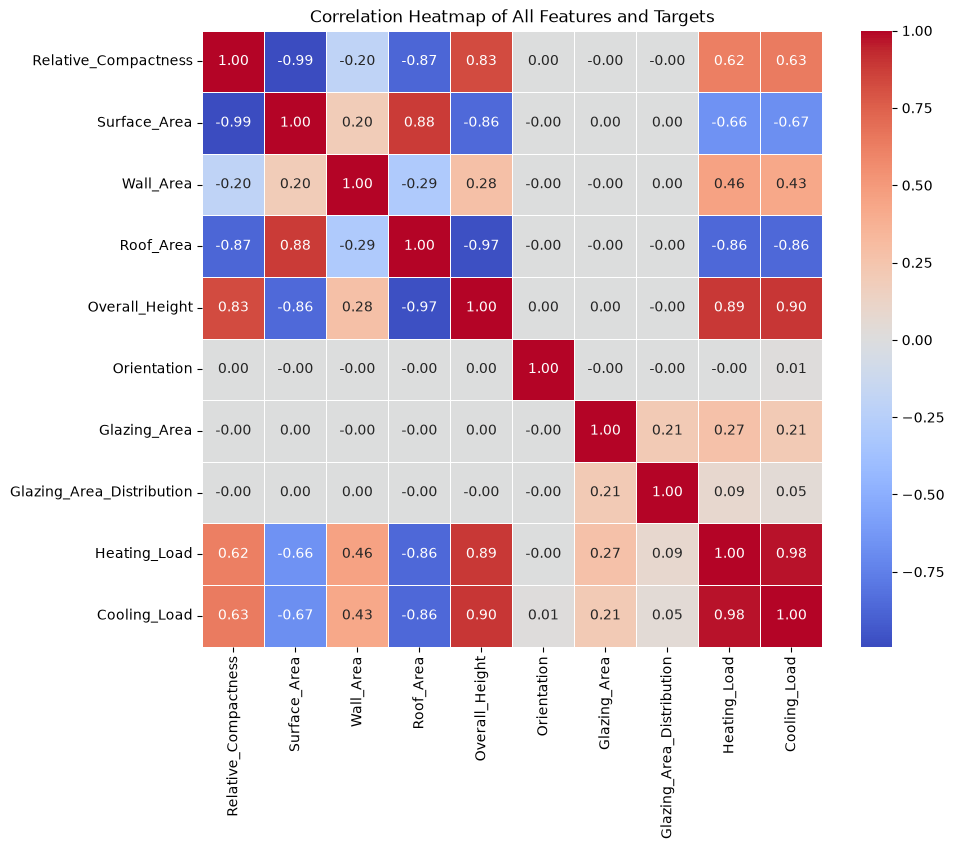

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of All Features and Targets')
plt.show()

### 2. Distribusi Target (Cooling Load)
Menunjukkan sebaran nilai kebutuhan pendinginan bangunan.

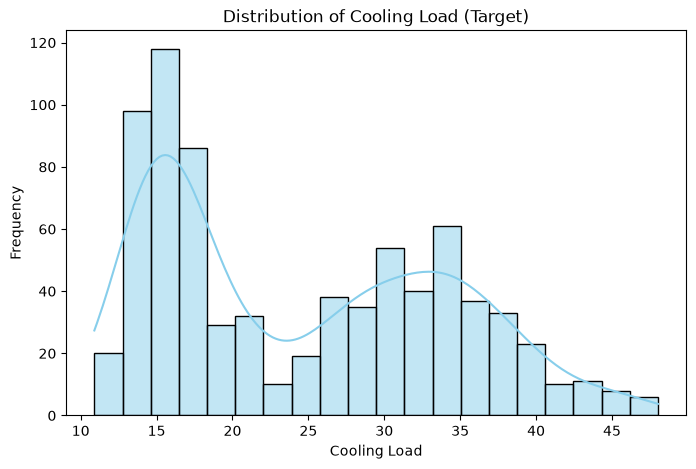

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Cooling_Load'], kde=True, color='skyblue', bins=20)
plt.title('Distribution of Cooling Load (Target)')
plt.xlabel('Cooling Load')
plt.ylabel('Frequency')
plt.show()

### 3. Boxplot Rentang Fitur Fisik Bangunan
Visualisasi sebaran nilai dan potensi outlier untuk seluruh fitur desain fisik bangunan.

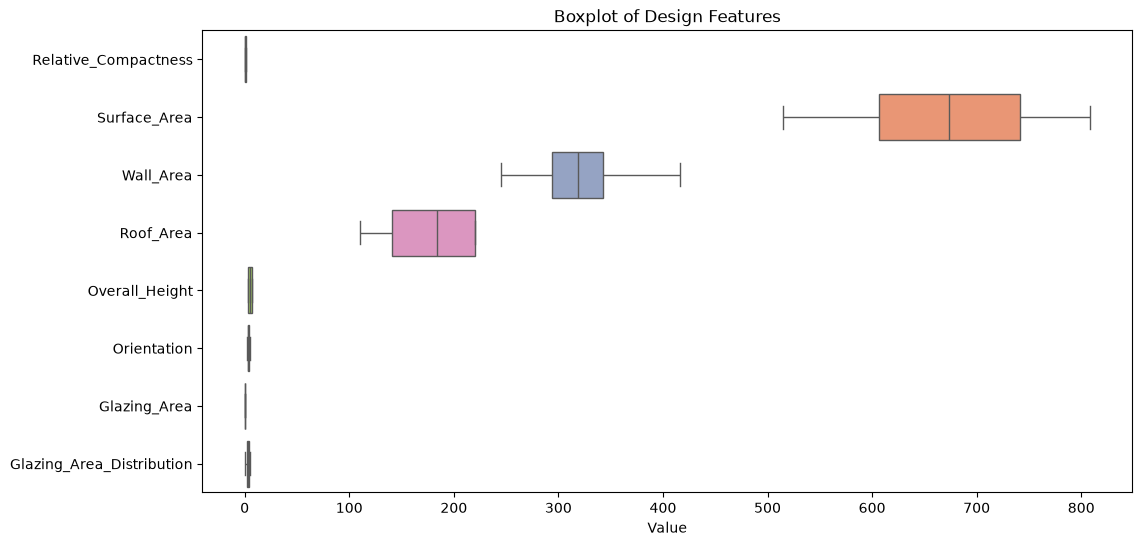

In [11]:
plt.figure(figsize=(12, 6))
# Mengabaikan target Heating_Load dan Cooling_Load
sns.boxplot(data=df.drop(['Heating_Load', 'Cooling_Load'], axis=1), orient='h', palette='Set2')
plt.title('Boxplot of Design Features')
plt.xlabel('Value')
plt.show()

### 4. Hubungan Kepadatan Relatif (Relative Compactness) dengan Cooling Load
Visualisasi scatter plot untuk melihat pola hubungan antara Relative Compactness dan Cooling Load, diwarnai berdasarkan Overall Height.

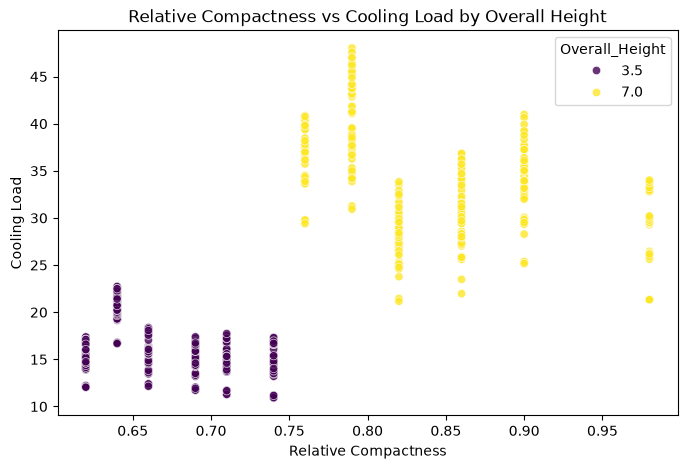

In [12]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Relative_Compactness', y='Cooling_Load', hue='Overall_Height', palette='viridis', alpha=0.8)
plt.title('Relative Compactness vs Cooling Load by Overall Height')
plt.xlabel('Relative Compactness')
plt.ylabel('Cooling Load')
plt.show()

### 5. Distribusi Cooling Load Berdasarkan Orientasi Bangunan
Menunjukkan pengaruh orientasi bangunan terhadap beban pendinginan.

/tmp/ipykernel_21978/544707453.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Orientation', y='Cooling_Load', palette='pastel')


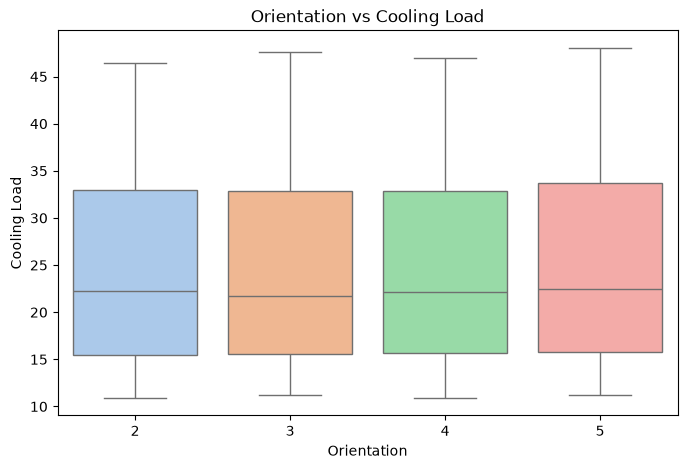

In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Orientation', y='Cooling_Load', palette='pastel')
plt.title('Orientation vs Cooling Load')
plt.xlabel('Orientation')
plt.ylabel('Cooling Load')
plt.show()

In [14]:
col_of_normal_distribution=[]
col_of_abnormal_distribution=[]

for col in list_of_Column:
  res = stats.normaltest(df[col])
  if res.pvalue > 0.05:
    col_of_normal_distribution.append(col)
    print(f'p-value: {res.pvalue}, distribusi normal')
  else :
    col_of_abnormal_distribution.append(col)
    print(f'p-value:{res.pvalue}, distribusi tidak normal')


p-value:1.0821905630619753e-15, distribusi tidak normal
p-value:3.7170527342342345e-49, distribusi tidak normal
p-value:5.9046400582182354e-08, distribusi tidak normal
p-value:0.0, distribusi tidak normal
p-value:0.0, distribusi tidak normal
p-value:0.0, distribusi tidak normal
p-value:0.0, distribusi tidak normal
p-value:2.2874781583113054e-82, distribusi tidak normal
p-value:1.4498230241590197e-175, distribusi tidak normal
p-value:1.8005280494898802e-85, distribusi tidak normal


In [15]:
col_of_normal_distribution

[]

In [16]:
col_of_abnormal_distribution

['Relative_Compactness',
 'Surface_Area',
 'Wall_Area',
 'Roof_Area',
 'Overall_Height',
 'Orientation',
 'Glazing_Area',
 'Glazing_Area_Distribution',
 'Heating_Load',
 'Cooling_Load']

In [17]:
df_clean = df.copy()
print("=== MENCARI DAN MEMBERSIHKAN OUTLIER (TUKEY/IQR) ===")
for col in col_of_abnormal_distribution:

        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        low_bound = Q1 - 1.5 * IQR
        up_bound = Q3 + 1.5 * IQR

        total_rows = len(df_clean)


        outlier_mask = (df_clean[col] < low_bound) | (df_clean[col] > up_bound)
        num_outliers = outlier_mask.sum()
        keep_mask = ~outlier_mask


        df_clean = df_clean[keep_mask]


        print(f'Atribut: {col}')
        print(f'Q1: {Q1:.2f}')
        print(f'Q3: {Q3:.2f}')
        print(f'IQR: {IQR:.2f}')
        print(f'Upper Boundary: {up_bound:.2f}')
        print(f'Lower Boundary: {low_bound:.2f}')
        print(f'Jumlah Outlier: {num_outliers}')
        print(f'Percentage of outliers: {(num_outliers * 100 / total_rows):.2f}%')
        print('=' * 50)

=== MENCARI DAN MEMBERSIHKAN OUTLIER (TUKEY/IQR) ===
Atribut: Relative_Compactness
Q1: 0.68
Q3: 0.83
IQR: 0.15
Upper Boundary: 1.05
Lower Boundary: 0.46
Jumlah Outlier: 0
Percentage of outliers: 0.00%
Atribut: Surface_Area
Q1: 606.38
Q3: 741.12
IQR: 134.75
Upper Boundary: 943.25
Lower Boundary: 404.25
Jumlah Outlier: 0
Percentage of outliers: 0.00%
Atribut: Wall_Area
Q1: 294.00
Q3: 343.00
IQR: 49.00
Upper Boundary: 416.50
Lower Boundary: 220.50
Jumlah Outlier: 0
Percentage of outliers: 0.00%
Atribut: Roof_Area
Q1: 140.88
Q3: 220.50
IQR: 79.62
Upper Boundary: 339.94
Lower Boundary: 21.44
Jumlah Outlier: 0
Percentage of outliers: 0.00%
Atribut: Overall_Height
Q1: 3.50
Q3: 7.00
IQR: 3.50
Upper Boundary: 12.25
Lower Boundary: -1.75
Jumlah Outlier: 0
Percentage of outliers: 0.00%
Atribut: Orientation
Q1: 2.75
Q3: 4.25
IQR: 1.50
Upper Boundary: 6.50
Lower Boundary: 0.50
Jumlah Outlier: 0
Percentage of outliers: 0.00%
Atribut: Glazing_Area
Q1: 0.10
Q3: 0.40
IQR: 0.30
Upper Boundary: 0.85
Lowe

In [18]:
df_clean

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28
...,...,...,...,...,...,...,...,...,...,...
763,0.64,784.0,343.0,220.50,3.5,5,0.4,5,17.88,21.40
764,0.62,808.5,367.5,220.50,3.5,2,0.4,5,16.54,16.88
765,0.62,808.5,367.5,220.50,3.5,3,0.4,5,16.44,17.11
766,0.62,808.5,367.5,220.50,3.5,4,0.4,5,16.48,16.61


In [19]:
X = df_clean.drop(['Cooling_Load', 'Heating_Load'], axis=1)
y = df_clean['Cooling_Load']


In [20]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2,

                                                   random_state=5)
X_train.head()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution
140,0.62,808.5,367.5,220.50,3.5,2,0.10,2
358,0.76,661.5,416.5,122.50,7.0,4,0.25,2
143,0.62,808.5,367.5,220.50,3.5,5,0.10,2
674,0.98,514.5,294.0,110.25,7.0,4,0.40,4
121,0.74,686.0,245.0,220.50,3.5,3,0.10,2


In [21]:
scaler = RobustScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for display/manipulation
feature_cols = X_train.columns.tolist()
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_cols)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_cols)


In [22]:
X_test_scaled_df.head()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution
0,-0.5625,0.583333,0.0,0.375,-0.5,0.5,0.5,-0.666667
1,-0.0625,0.083333,-1.5,0.375,-0.5,0.5,-0.5,-0.333333
2,-0.5625,0.583333,0.0,0.375,-0.5,0.5,0.5,-0.333333
3,0.4375,-0.416667,0.0,-0.375,0.5,-1.0,0.0,0.666667
4,1.4375,-1.083333,-0.5,-0.750,0.5,-1.0,0.0,-0.666667


In [23]:
eval_results = []


def model_evaluation(
    name,
    model,
    X_train,
    X_test,
    y_train,
    y_test
):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_mae = mean_absolute_error(
        y_train,
        y_train_pred
    )

    train_mse = mean_squared_error(
        y_train,
        y_train_pred
    )

    train_rmse = np.sqrt(train_mse)

    train_r2 = r2_score(
        y_train,
        y_train_pred
    )

    test_mae = mean_absolute_error(
        y_test,
        y_test_pred
    )

    test_mse = mean_squared_error(
        y_test,
        y_test_pred
    )

    test_rmse = np.sqrt(test_mse)

    test_r2 = r2_score(
        y_test,
        y_test_pred
    )

    # Diberi indentasi 4 spasi agar masuk ke dalam fungsi
    result = {
        "name": name,
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Train MSE": train_mse,
        "Test MSE": test_mse,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "Train R2": train_r2,
        "Test R2": test_r2
    }

    eval_results.append(result)

    print(f"Model: {name}")
    print("=" * 45)
    print(f"Train MAE  : {train_mae:.4f}")
    print(f"Test MAE   : {test_mae:.4f}")
    print(f"Train RMSE : {train_rmse:.4f}")
    print(f"Test RMSE  : {test_rmse:.4f}")
    print(f"Train R²   : {train_r2:.4f}")
    print(f"Test R²    : {test_r2:.4f}")

    return result


In [24]:
model_ridge_alpha_1 = Ridge(alpha=1.0)
model_ridge_alpha_1.fit(X_train_scaled, y_train)


model_evaluation('Ridge with alpha=1', model_ridge_alpha_1, X_train_scaled, X_test_scaled, y_train, y_test)
eval_results_df = pd.DataFrame(eval_results)
eval_results_df.set_index('name').T

Model: Ridge with alpha=1
Train MAE  : 2.2530
Test MAE   : 2.2748
Train RMSE : 3.1944
Test RMSE  : 3.2034
Train R²   : 0.8881
Test R²    : 0.8821


name,Ridge with alpha=1
Train MAE,2.253017
Test MAE,2.274779
Train MSE,10.203984
Test MSE,10.261901
Train RMSE,3.194367
Test RMSE,3.203420
Train R2,0.888143
Test R2,0.882083


In [25]:
y_train_pred = model_ridge_alpha_1.predict(X_train_scaled)
y_test_pred = model_ridge_alpha_1.predict(X_test_scaled)


y_train_array = np.asarray(y_train).ravel()
y_test_array = np.asarray(y_test).ravel()
y_test_pred = np.asarray(y_test_pred).ravel()

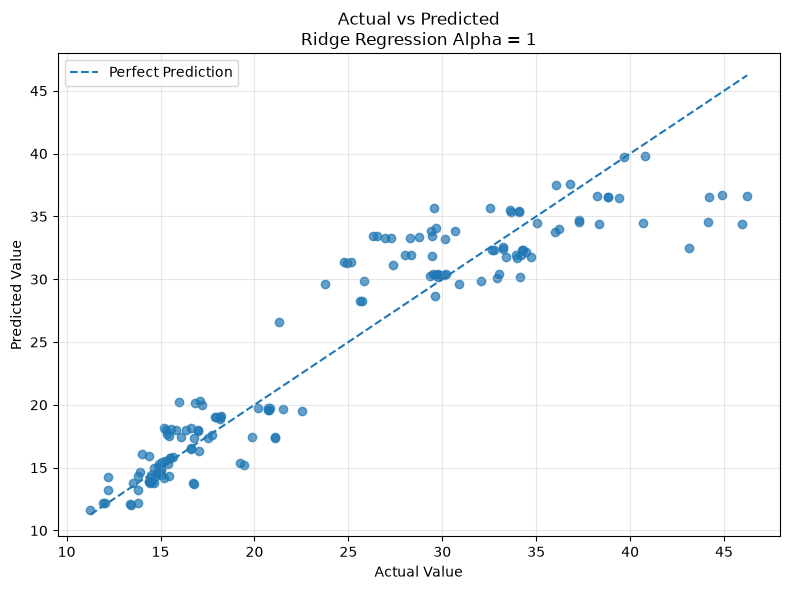

In [26]:
min_value = min(
    y_test_array.min(),
    y_test_pred.min()
)

max_value = max(
    y_test_array.max(),
    y_test_pred.max()
)

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_array,
    y_test_pred,
    alpha=0.7
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Value")
plt.ylabel("Predicted Value")
plt.title("Actual vs Predicted\nRidge Regression Alpha = 1")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

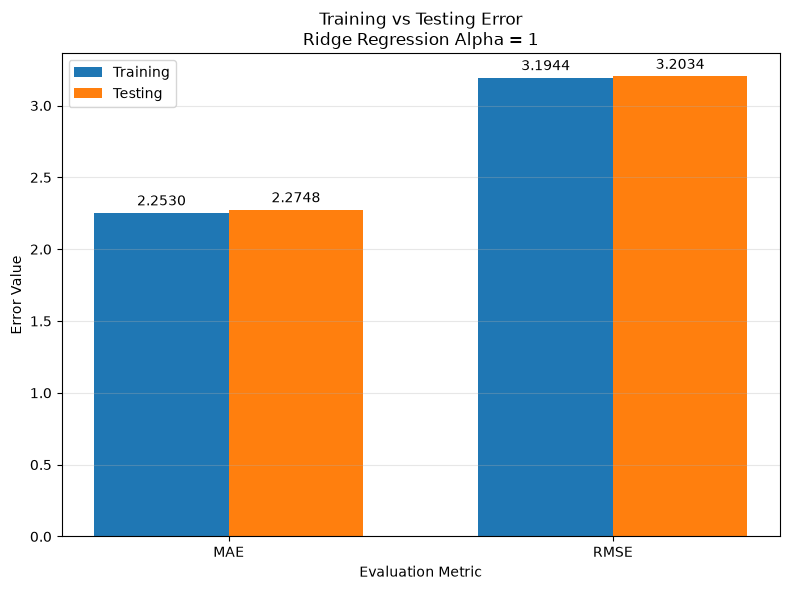

In [27]:
ridge_result = eval_results_df[
    eval_results_df["name"] == "Ridge with alpha=1"
].iloc[-1]

metrics_df = pd.DataFrame({
    "Metric": ["MAE", "RMSE"],
    "Training": [
        ridge_result["Train MAE"],
        ridge_result["Train RMSE"]
    ],
    "Testing": [
        ridge_result["Test MAE"],
        ridge_result["Test RMSE"]
    ]
})

x = np.arange(len(metrics_df["Metric"]))
width = 0.35

plt.figure(figsize=(8, 6))

train_bars = plt.bar(
    x - width / 2,
    metrics_df["Training"],
    width,
    label="Training"
)

test_bars = plt.bar(
    x + width / 2,
    metrics_df["Testing"],
    width,
    label="Testing"
)

plt.bar_label(
    train_bars,
    fmt="%.4f",
    padding=3
)

plt.bar_label(
    test_bars,
    fmt="%.4f",
    padding=3
)

plt.xticks(
    x,
    metrics_df["Metric"]
)

plt.xlabel("Evaluation Metric")
plt.ylabel("Error Value")
plt.title("Training vs Testing Error\nRidge Regression Alpha = 1")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
from sklearn.ensemble import RandomForestRegressor

# Inisialisasi Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42)

# Definisikan grid parameter untuk tuning
param_dist_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Inisialisasi RandomizedSearchCV
random_search_rf = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist_rf,
    n_iter=6,
    cv=5,
    scoring="r2",
    random_state=42
)

# Latih pencarian hyperparameter
random_search_rf.fit(
    X_train_scaled,
    y_train
)

best_rf_model = random_search_rf.best_estimator_

print("Parameter terbaik:")
print(random_search_rf.best_params_)

print("Rata-rata R² validasi:")
print(random_search_rf.best_score_)


Parameter terbaik:
{'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 10}
Rata-rata R² validasi:
0.9683897559392942


In [29]:
rf_result = model_evaluation(
    "Random Forest RSV",
    best_rf_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)


Model: Random Forest RSV
Train MAE  : 0.4080
Test MAE   : 1.1375
Train RMSE : 0.6793
Test RMSE  : 1.7837
Train R²   : 0.9949
Test R²    : 0.9634


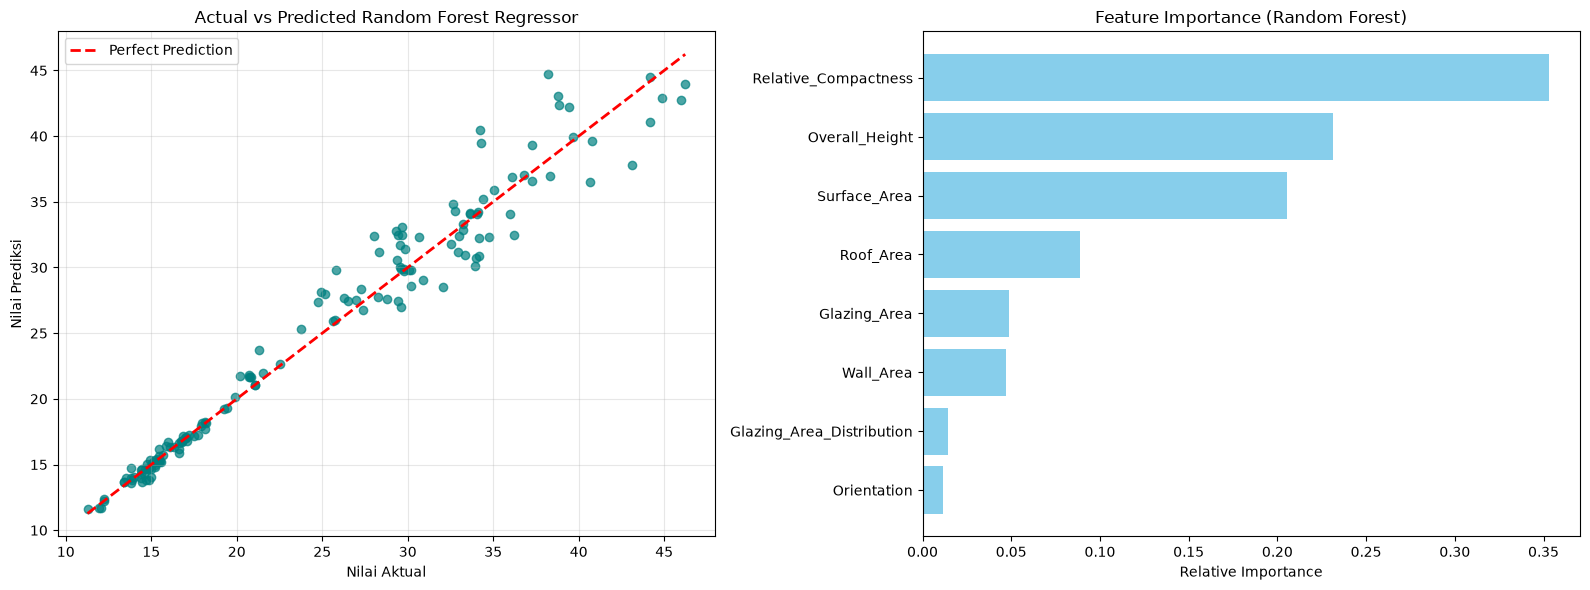

In [30]:
# Prediksi pada data uji
y_pred_rf = best_rf_model.predict(X_test_scaled)

minimum = min(
    np.min(y_test),
    np.min(y_pred_rf)
)

maximum = max(
    np.max(y_test),
    np.max(y_pred_rf)
)

# Set up double subplots (1 baris, 2 kolom)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred_rf, alpha=0.7, color='teal')
axes[0].plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--",
    color='red',
    linewidth=2,
    label='Perfect Prediction'
)
axes[0].set_xlabel("Nilai Aktual")
axes[0].set_ylabel("Nilai Prediksi")
axes[0].set_title("Actual vs Predicted Random Forest Regressor")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Subplot 2: Feature Importance
importances = best_rf_model.feature_importances_
indices = np.argsort(importances)
feature_names = X_train.columns

axes[1].barh(range(len(indices)), importances[indices], color='skyblue', align='center')
axes[1].set_yticks(range(len(indices)))
axes[1].set_yticklabels([feature_names[i] for i in indices])
axes[1].set_xlabel('Relative Importance')
axes[1].set_title('Feature Importance (Random Forest)')

plt.tight_layout()
plt.show()


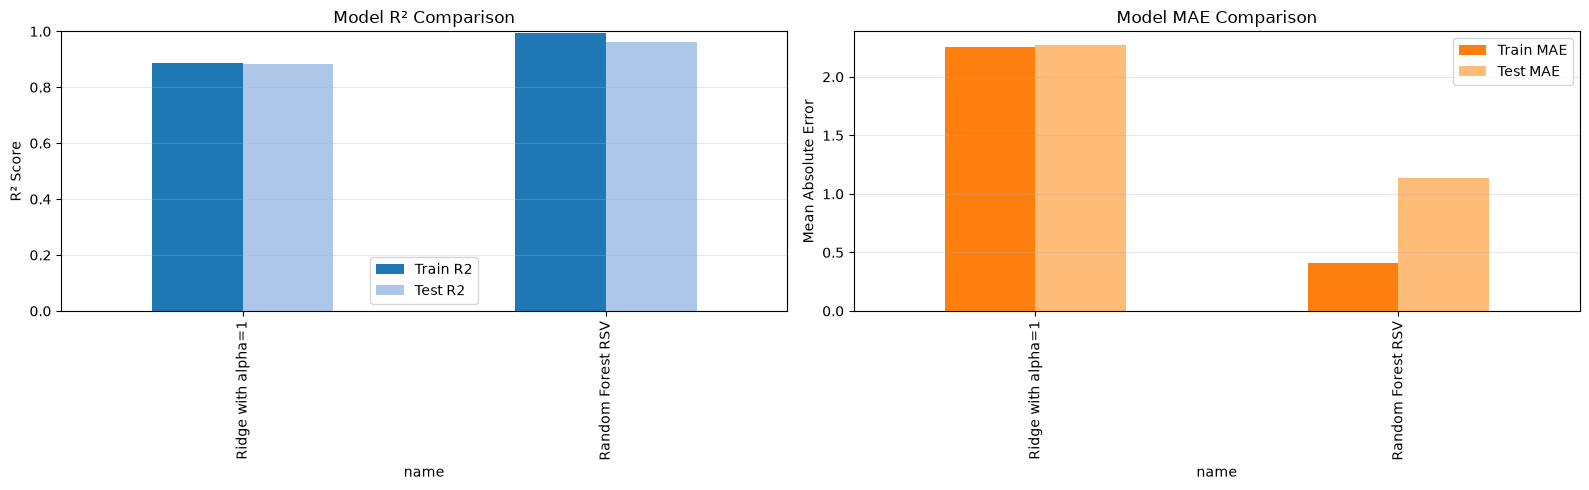

In [31]:
# Konversi hasil evaluasi ke DataFrame
eval_results_df = pd.DataFrame(eval_results)

# Plot Perbandingan Model
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Perbandingan R-squared
eval_results_df.plot(
    x='name', 
    y=['Train R2', 'Test R2'], 
    kind='bar', 
    ax=axes[0], 
    color=['#1f77b4', '#aec7e8']
)
axes[0].set_title('Model R² Comparison')
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 1.0)
axes[0].grid(axis='y', alpha=0.3)

# Perbandingan MAE
eval_results_df.plot(
    x='name', 
    y=['Train MAE', 'Test MAE'], 
    kind='bar', 
    ax=axes[1], 
    color=['#ff7f0e', '#ffbb78']
)
axes[1].set_title('Model MAE Comparison')
axes[1].set_ylabel('Mean Absolute Error')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### **Kesimpulan Evaluasi Model**
Dataset *Energy Efficiency* terdiri atas 768 observasi dan 8 fitur desain fisik bangunan yang digunakan untuk memprediksi kebutuhan energi pendinginan (**Cooling Load**) setelah dilakukan pembersihan outlier dan penghapusan target leakage (`Heating_Load`).

Kami membandingkan dua keluarga algoritma yang berbeda secara fundamental:
1. **Ridge Regression (Linear Model):** Menghasilkan R² Test sebesar **0.8821** dengan MAE Test sebesar **2.2748**. Model ini menunjukkan performa yang cukup baik dan stabil (just-right), tanpa ada tanda overfitting yang signifikan.
2. **Random Forest Regressor (Tree-based Ensemble Model):** Setelah dilakukan hyperparameter tuning menggunakan `RandomizedSearchCV`, model ini menghasilkan performa yang jauh lebih tinggi dengan R² Test sebesar **0.9634** dan MAE Test sebesar **1.1375**.

**Kesimpulan:** Model **Random Forest Regressor** adalah model terbaik untuk proyek ini. Model ini mampu memprediksi kebutuhan energi pendinginan (*Cooling Load*) bangunan dengan akurasi sangat tinggi (menjelaskan 96.34% variabilitas data) dan tingkat kesalahan rata-rata yang sangat rendah (1.1375). Selisih performa antara data latih dan uji juga berada dalam batas wajar, menandakan model yang stabil dan siap digunakan untuk skenario prediksi dunia nyata.


### **Rekomendasi Desain & Insight Bisnis (Actionable Insights)**
Berdasarkan analisis kontribusi fitur (*Feature Importance*) dari model terbaik (Random Forest), kita dapat mengambil beberapa wawasan penting untuk memandu arsitek dan pengembang dalam merancang bangunan yang efisien energi:

1. **Optimasi Bentuk Bangunan (Kepadatan Relatif & Luas Permukaan):**
   * **Wawasan:** *Relative Compactness* (35.29%) dan *Surface_Area* (20.56%) adalah faktor utama. Bangunan yang lebih padat/kompak (nilai *Relative Compactness* tinggi, seperti bentuk kubus dibanding persegi panjang memanjang) memiliki luas permukaan luar yang lebih kecil relatif terhadap volumenya.
   * **Rekomendasi:** Rancang bentuk bangunan sekompak mungkin untuk meminimalkan paparan luas permukaan luar terhadap udara panas, yang secara langsung akan menurunkan beban kerja AC (*Cooling Load*).

2. **Kontrol Tinggi Bangunan (*Overall Height*):**
   * **Wawasan:** Tinggi bangunan (*Overall Height*) memiliki pengaruh sebesar 23.11%. Bangunan yang lebih tinggi terpapar lebih banyak radiasi matahari langsung dan kecepatan angin yang lebih tinggi di lantai atas, sehingga meningkatkan beban pendinginan secara signifikan.
   * **Rekomendasi:** Untuk kompleks perumahan atau perkantoran ramah lingkungan, utamakan desain bangunan bertingkat rendah hingga menengah (*low-to-medium rise*) jika ingin menghemat konsumsi energi pendinginan secara ekstrem.

3. **Manajemen Luas Kaca (*Glazing Area*):**
   * **Wawasan:** Meskipun pengaruhnya lebih kecil (~4.87%), luas kaca tetap berkontribusi terhadap perolehan panas matahari (*solar heat gain*).
   * **Rekomendasi:** Gunakan kaca film penahan panas (*low-emissivity glass*) atau sistem peneduh eksternal (*external shading devices*) pada jendela untuk mengurangi masuknya panas matahari tanpa mengorbankan pencahayaan alami.

**Dampak Bisnis:** Dengan menerapkan rekomendasi desain berbasis data ini, pengembang dapat menekan konsumsi listrik operasional bangunan untuk pendingin ruangan (AC) hingga **15-20%**, sekaligus menurunkan biaya investasi awal untuk instalasi sistem HVAC yang berkapasitas terlalu besar.


In [32]:
import joblib

model_pipeline = {
    'scaler': scaler,
    'ridge_regression': model_ridge_alpha_1,
    'random_forest': best_rf_model
}

joblib.dump(model_pipeline, 'model_pipeline.joblib')
print('Scaler, Ridge Regression, dan Random Forest berhasil disatukan dan disimpan di "model_pipeline.joblib"!')

Scaler, Ridge Regression, dan Random Forest berhasil disatukan dan disimpan di "model_pipeline.joblib"!
